In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm


## Plot correlations

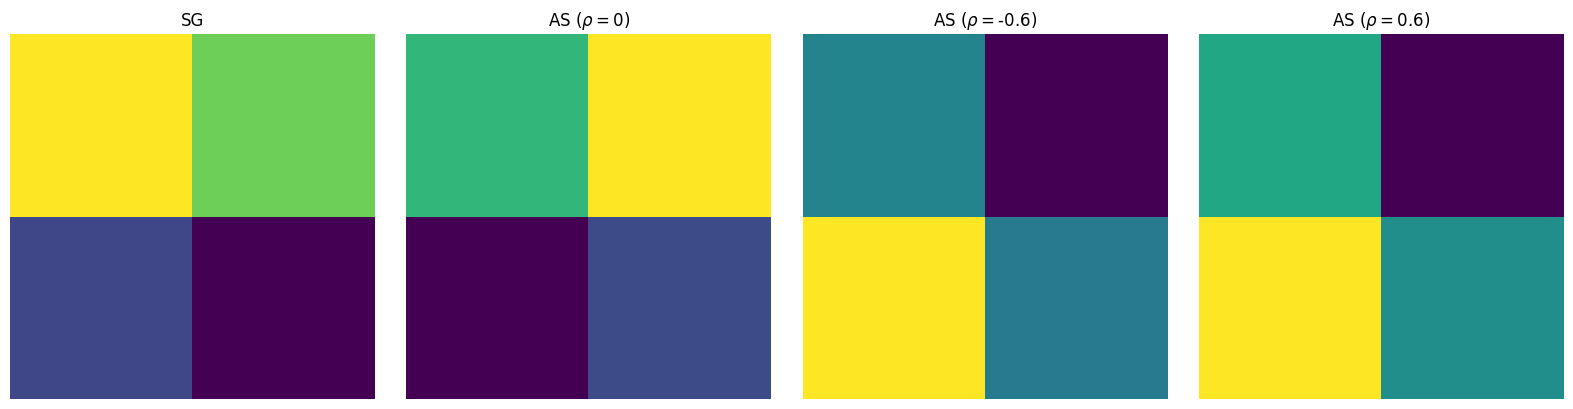

In [17]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 2
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0, -0.6, 0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [23]:
m = SocialGPModel(
    child_maps=[parent] + child_maps,
    n=n_children,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.0, -0.6, 0.6]),
    length_scale_private=1.11,
    length_scale_social=1.11,
    observation_noise_private=0.0001,
    observation_noise_social=3,
    tau=0.03,
    beta_private=0.33,
    beta_social=0.33,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type
Step AgentID                                                
1    1        (0, 0)  0.508191           0.508191         SG
     2        (0, 0)  0.516578           0.516578         AS
     3        (1, 0)  0.399557           0.399557         AS
     4        (1, 0)  0.162516           0.162516         AS
2    1        (1, 1) -0.508775          -0.500584         SG
     2        (0, 1) -0.086026          -0.069449         AS
     3        (0, 0)  0.121055           0.020612         AS
     4        (0, 1) -0.282084          -0.619568         AS
3    1        (0, 0)  0.484505          -0.516078         SG
     2        (1, 0) -0.053029          -0.622478         AS
     3        (1, 1)  0.341735          -0.137653         AS
     4        (1, 1)  0.500429          -0.619140         AS
4    1        (0, 0)  0.514001          -0.502078         SG
     2        (0, 0)  0.514741          -0.607736         AS
     3        (0, 1)  0.047399          -0.590254         AS
     4        (1, 1)  0.492216          -0.626924         AS
5    1        (0, 0)  0.494989          -0.507088         SG
     2        (0, 0)  0.501093          -0.606643         AS
     3        (1, 0)  0.403044          -0.687210         AS
     4        (1, 1)  0.503670          -0.623254         AS